# Notebook 02: Exploratory Data Analysis (EDA)

## AI Emotion RAG Assistant

This notebook performs an exploratory analysis of the GoEmotions dataset before preprocessing and model training.

**Objectives**
- Inspect dataset structure
- Check data quality
- Analyze emotion labels
- Analyze sentence lengths
- Analyze multi-label distribution
- Export statistics and figures


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")
plt.rcParams["figure.figsize"]=(12,6)

PROJECT_ROOT = Path.cwd().parent
DATASET_DIR = PROJECT_ROOT / "datasets"
RAW_DIR = DATASET_DIR / "raw"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

EMOTION_PATH = RAW_DIR / "emotion" / "go_emotions_dataset.csv"


## Load Dataset

In [2]:
df = pd.read_csv(EMOTION_PATH)

display(df.head())
print(df.shape)
df.info()

,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eew5j0j,That game hurt.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,eemcysk,>sexuality shouldn’t be a grouping category I...,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ed2mah1,"You do right, if you don't care then fuck 'em!",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,eeibobj,Man I love reddit.,False,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,eda6yn6,"[NAME] was nowhere near them, he was by the Fa...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


(211225, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211225 entries, 0 to 211224
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   id                    211225 non-null  object
 1   text                  211225 non-null  object
 2   example_very_unclear  211225 non-null  bool  
 3   admiration            211225 non-null  int64 
 4   amusement             211225 non-null  int64 
 5   anger                 211225 non-null  int64 
 6   annoyance             211225 non-null  int64 
 7   approval              211225 non-null  int64 
 8   caring                211225 non-null  int64 
 9   confusion             211225 non-null  int64 
 10  curiosity             211225 non-null  int64 
 11  desire                211225 non-null  int64 
 12  disappointment        211225 non-null  int64 
 13  disapproval           211225 non-null  int64 
 14  disgust               211225 non-null  int64 
 15  emba

## Data Quality

In [3]:
emotion_columns = list(df.columns[3:])

summary = {
    "Samples": len(df),
    "Features": len(df.columns),
    "Emotion Labels": len(emotion_columns),
    "Missing Values": int(df.isnull().sum().sum()),
    "Duplicate Rows": int(df.duplicated().sum()),
    "Duplicate Text": int(df["text"].duplicated().sum()),
    "Empty Text": int(df["text"].fillna("").str.strip().eq("").sum())
}

pd.DataFrame(summary.items(), columns=["Metric","Value"])

,Metric,Value
0,Samples,211225
1,Features,31
2,Emotion Labels,28
3,Missing Values,0
4,Duplicate Rows,56737
5,Duplicate Text,153493
6,Empty Text,0


## Emotion Distribution

,Frequency
neutral,55298
approval,17620
admiration,17131
annoyance,13618
gratitude,11625
disapproval,11424
curiosity,9692
amusement,9245
realization,8785
optimism,8715


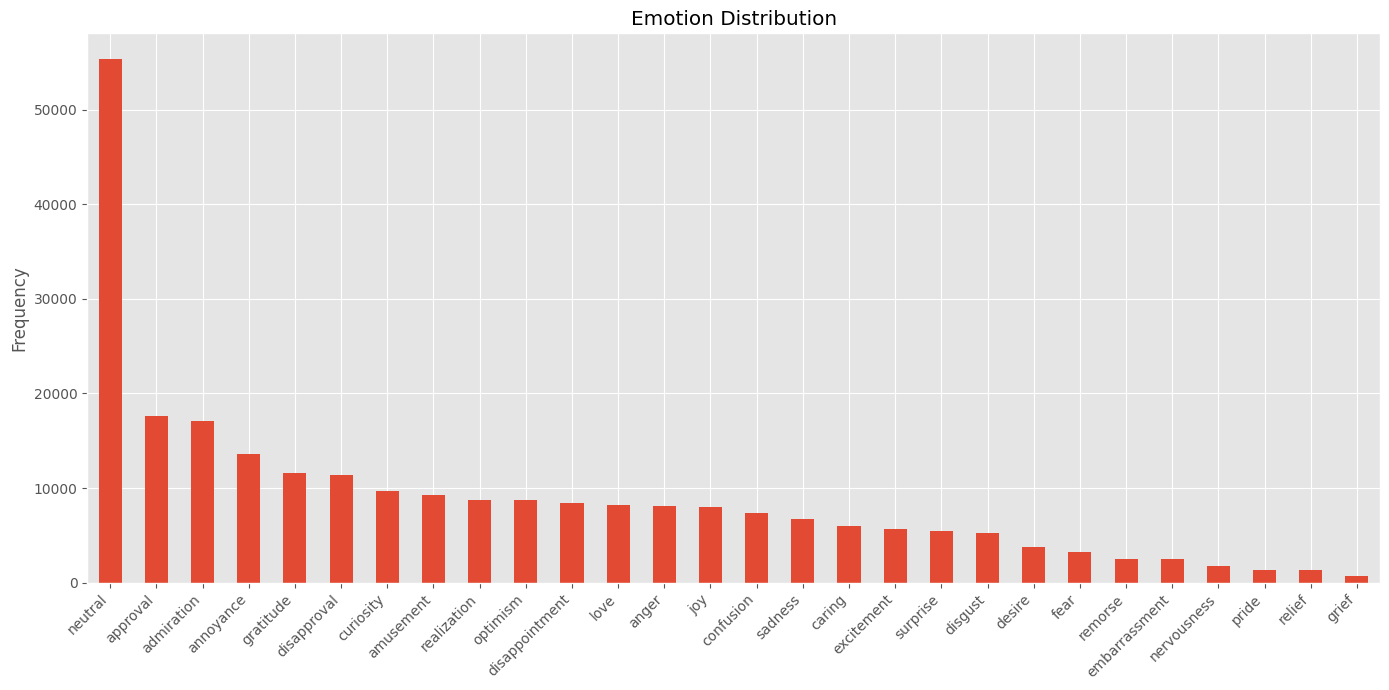

In [4]:
emotion_frequency = (
    df[emotion_columns]
    .sum()
    .sort_values(ascending=False)
)

display(emotion_frequency.to_frame("Frequency"))

emotion_frequency.to_csv(TABLE_DIR/"emotion_frequency.csv")

plt.figure(figsize=(14,7))
emotion_frequency.plot(kind="bar")
plt.title("Emotion Distribution")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR/"emotion_distribution.png", dpi=300)
plt.show()


## Sentence Length

count    211225.000000
mean         12.997188
std           6.676105
min           1.000000
25%           7.000000
50%          13.000000
75%          18.000000
max          33.000000
Name: word_count, dtype: float64

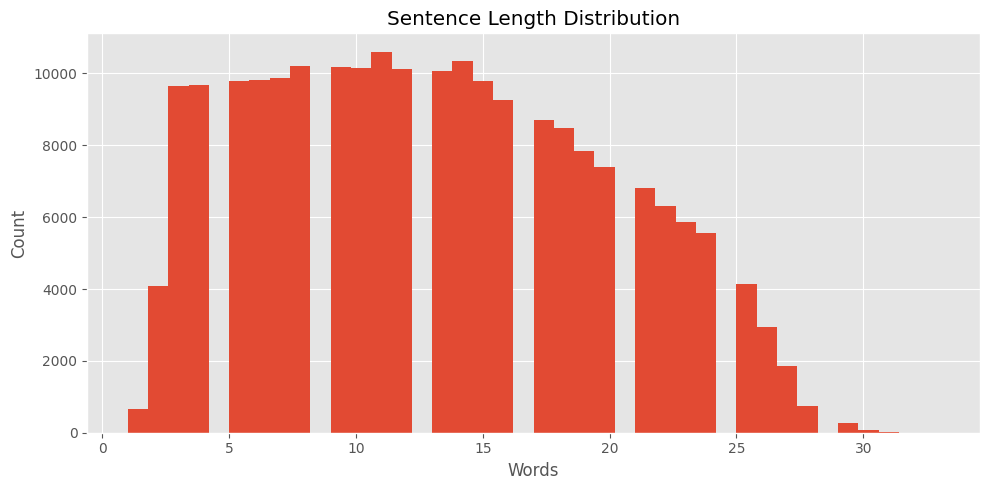

In [5]:
df["word_count"] = df["text"].str.split().apply(len)

display(df["word_count"].describe())

plt.figure(figsize=(10,5))
plt.hist(df["word_count"], bins=40)
plt.title("Sentence Length Distribution")
plt.xlabel("Words")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURE_DIR/"sentence_length_distribution.png", dpi=300)
plt.show()


## Multi-label Analysis

num_labels
0       3411
1     171820
2      31187
3       4218
4        399
5        106
6         53
7         20
8          6
9          3
10         1
12         1
Name: count, dtype: int64

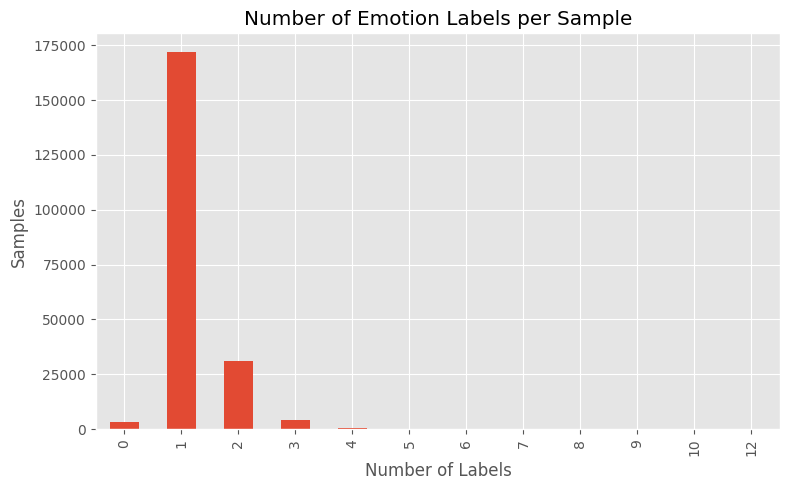

In [6]:
df["num_labels"] = df[emotion_columns].sum(axis=1)

label_distribution = (
    df["num_labels"]
    .value_counts()
    .sort_index()
)

display(label_distribution)

label_distribution.to_csv(TABLE_DIR/"label_distribution.csv")

plt.figure(figsize=(8,5))
label_distribution.plot(kind="bar")
plt.title("Number of Emotion Labels per Sample")
plt.xlabel("Number of Labels")
plt.ylabel("Samples")
plt.tight_layout()
plt.savefig(FIGURE_DIR/"multi_label_distribution.png", dpi=300)
plt.show()


## Top Words

In [7]:
counter = Counter()

for sentence in df["text"]:
    counter.update(str(sentence).lower().split())

top_words = pd.DataFrame(
    counter.most_common(30),
    columns=["Word","Frequency"]
)

display(top_words)

top_words.to_csv(TABLE_DIR/"top_words.csv", index=False)


,Word,Frequency
0,the,88004
1,i,77970
2,to,62046
3,a,61017
4,and,43882
5,you,41865
6,is,39857
7,that,35321
8,of,34929
9,it,30849


## Emotion Correlation

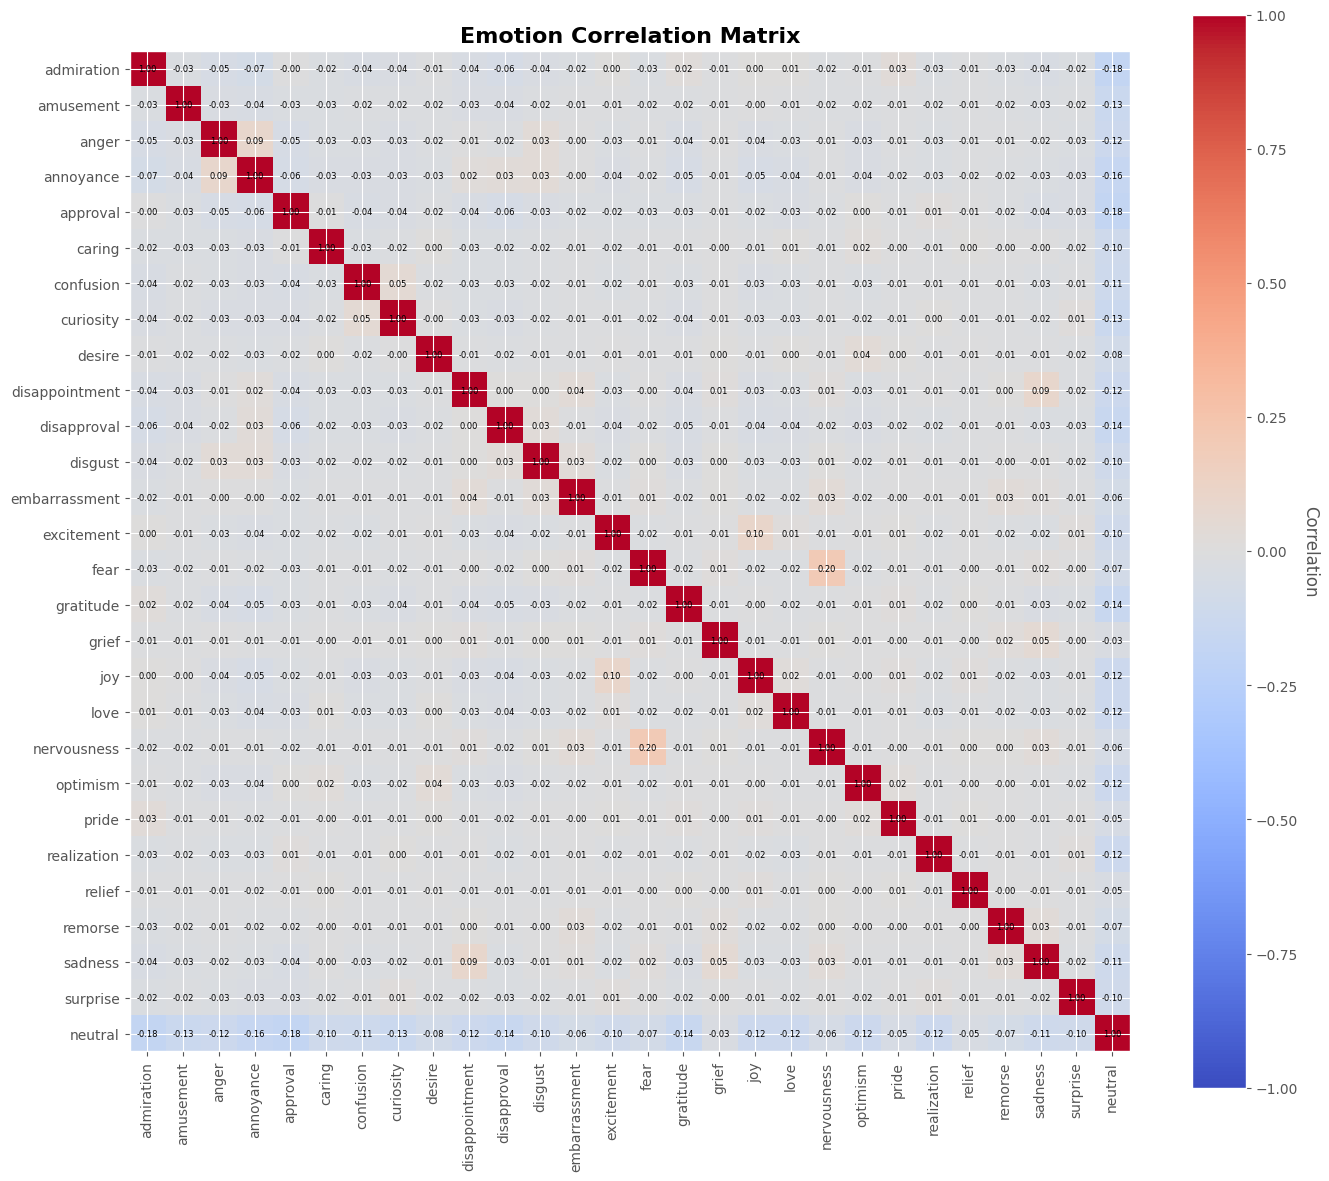

In [10]:
corr = df[emotion_columns].corr()

fig, ax = plt.subplots(figsize=(14, 12))

im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# Tick labels
ax.set_xticks(np.arange(len(emotion_columns)))
ax.set_yticks(np.arange(len(emotion_columns)))

ax.set_xticklabels(emotion_columns, rotation=90)
ax.set_yticklabels(emotion_columns)

# Hiển thị giá trị correlation
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=6,
            color="black"
        )

# Colorbar
cbar = plt.colorbar(im)
cbar.set_label("Correlation", rotation=270, labelpad=15)

plt.title("Emotion Correlation Matrix", fontsize=16, fontweight="bold")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "emotion_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Export Summary

In [ ]:
dataset_summary = pd.DataFrame(summary.items(), columns=["Metric","Value"])
dataset_summary.to_csv(TABLE_DIR/"dataset_summary.csv", index=False)


EDA completed successfully!

Generated files:
- outputs/figures/emotion_distribution.png
- outputs/figures/sentence_length_distribution.png
- outputs/figures/multi_label_distribution.png
- outputs/figures/emotion_correlation.png
- outputs/tables/dataset_summary.csv
- outputs/tables/emotion_frequency.csv
- outputs/tables/label_distribution.csv
- outputs/tables/top_words.csv
